In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Importação do dataset
df = pd.read_csv("mecaniqa_dataset.csv")

# Preparação dos dados
df.columns = df.columns.str.strip()

df["Data"] = pd.to_datetime(
    df["Data"],
    format="%Y-%m-%d",
    errors="raise"
)

df = df.set_index("Data")
df = df.sort_index()

In [4]:
# Seleciona a série de trocas de óleo
serie_oleo = df["Trocas_Oleo"].copy()

# Preenche os valores ausentes por interpolação temporal
serie_oleo = serie_oleo.interpolate(method="time")
serie_oleo = serie_oleo.ffill().bfill()

print("Valores ausentes após o tratamento:", serie_oleo.isnull().sum())

Valores ausentes após o tratamento: 0


In [5]:
# Decisões do brainstorm
modelo_escolhido = "additive"
periodo_escolhido = 7

# Média móvel de sete dias
media_movel_7_dias = serie_oleo.rolling(
    window=periodo_escolhido,
    center=True
).mean()

print("\nPrimeiros valores da média móvel:")
display(media_movel_7_dias.dropna().head())


Primeiros valores da média móvel:


Data
2024-01-04    18.285714
2024-01-05    18.571429
2024-01-06    18.714286
2024-01-07    18.857143
2024-01-08    18.142857
Name: Trocas_Oleo, dtype: float64

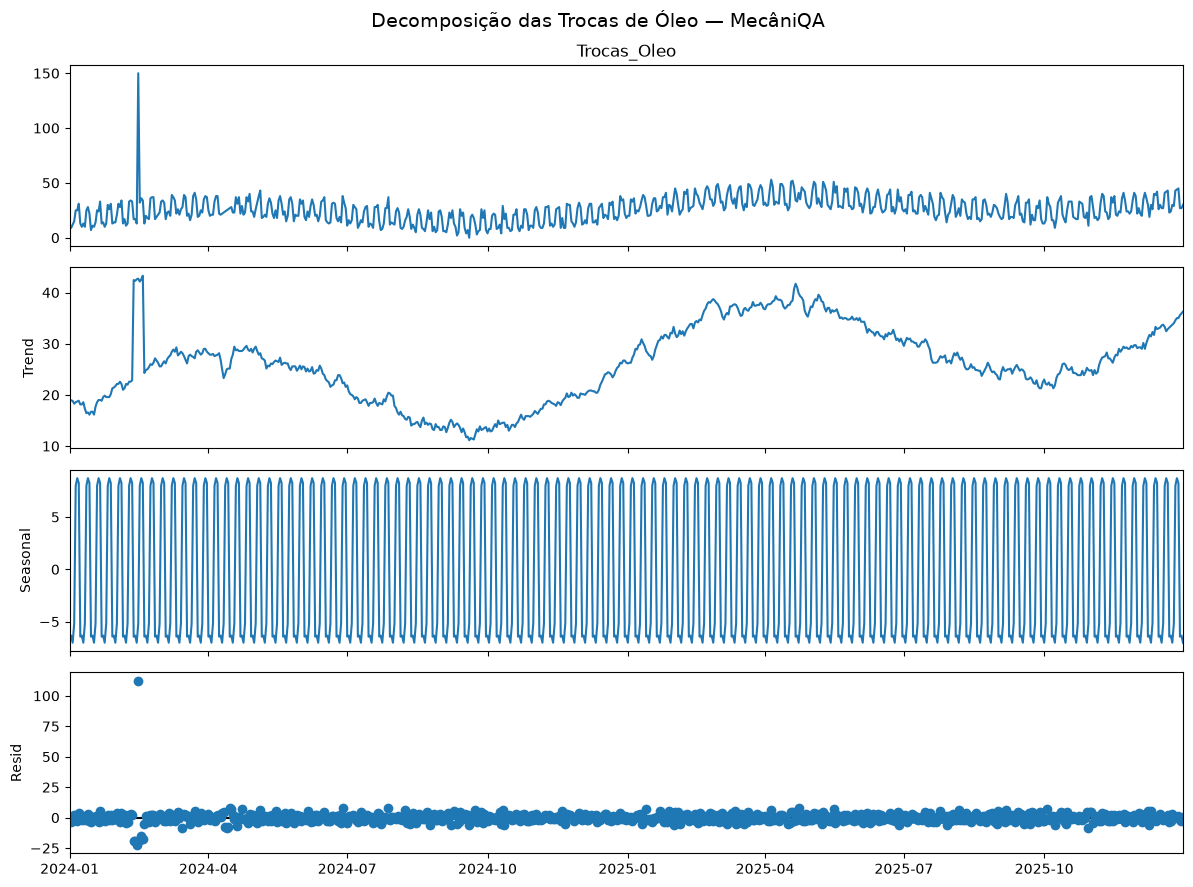

Modelo escolhido: additive
Período escolhido: 7 dias


In [6]:
# Decomposição temporal
resultado = seasonal_decompose(
    serie_oleo,
    model=modelo_escolhido,
    period=periodo_escolhido,
    extrapolate_trend=periodo_escolhido
)

# Gera os quatro gráficos
fig = resultado.plot()

fig.set_size_inches(12, 9)
fig.suptitle(
    "Decomposição das Trocas de Óleo — MecâniQA",
    fontsize=14
)

fig.tight_layout()
plt.show()

print("Modelo escolhido:", modelo_escolhido)
print("Período escolhido:", periodo_escolhido, "dias")